In [ ]:
pip install pandas numpy scikit-learn imbalanced-learn shap xgboost

In [ ]:
import pandas as pd


data = pd.read_csv("kidney_disease.csv")

print(f"Dataset Shape: {data.shape}")


data.rename(columns={'classification': 'Class'}, inplace=True)


print("Columns in dataset:", data.columns.tolist())


print("\nValue counts for 'Class':")
print(data['Class'].value_counts())

Dataset Shape: (400, 26)
Columns in dataset: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'Class']

Value counts for 'Class':
Class
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd


data = pd.read_csv("kidney_disease.csv")


data.rename(columns={'classification': 'Class'}, inplace=True)


data['Class'] = data['Class'].str.replace(r'\t', '', regex=True).str.strip()


X = data.drop("Class", axis=1)
y = data["Class"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 320
Testing set size: 80


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


data = pd.read_csv("kidney_disease.csv")


numeric_columns = ['pcv', 'wc', 'rc', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

for col in numeric_columns:

    data[col] = pd.to_numeric(data[col], errors='coerce')

data['classification'] = data['classification'].str.replace(r'\t', '', regex=True).str.strip()
data.rename(columns={'classification': 'Class'}, inplace=True)

X = data.drop(["Class", "id"], axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


num_cols = X_train.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

print("Data successfully cleaned, imputed, and scaled!")

Data successfully cleaned, imputed, and scaled!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

data = pd.read_csv("kidney_disease.csv")


num_cols = ['pcv', 'wc', 'rc', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data['classification'] = data['classification'].str.replace(r'\t', '', regex=True).str.strip()
le = LabelEncoder()
data['Class'] = le.fit_transform(data['classification']) # ckd=0, notckd=1 (usually)

data_encoded = pd.get_dummies(data.drop(['id', 'classification'], axis=1), drop_first=True)


X = data_encoded.drop("Class", axis=1)
y = data_encoded["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)


train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)


major_class = train_data[train_data.Class == 0]
minor_class = train_data[train_data.Class == 1]


minor_upsampled = resample(minor_class,
                           replace=True,
                           n_samples=len(major_class),
                           random_state=42)

bal_data = pd.concat([major_class, minor_upsampled])
X_train_bal = bal_data.drop('Class', axis=1)
y_train_bal = bal_data['Class']


scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)


models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="logloss")
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

print("Success: X_train_bal and y_train_bal are defined and all models are trained.")

Success: X_train_bal and y_train_bal are defined and all models are trained.


In [ ]:
from sklearn.metrics import average_precision_score

model_scores = {}

for name, model in trained_models.items():
    probs = model.predict_proba(X_test_scaled)[:,1]
    score = average_precision_score(y_test, probs)
    model_scores[name] = score

print(model_scores)

{'LR': np.float64(0.9999999999999999), 'RF': np.float64(1.0), 'GB': np.float64(1.0), 'KNN': np.float64(0.9989247311827957), 'SVM': np.float64(0.9999999999999999), 'XGB': np.float64(0.9999999999999999)}


In [ ]:


selected_models = {
    name: model for name, model in trained_models.items()
    if model_scores[name] > 0.99899 and model_scores[name] != 1.0
}

print(f"Models meeting the criteria (0.998 < score < 1.0): {list(selected_models.keys())}")

if not selected_models:
    print("No models met the specific criteria. You may need to adjust the threshold or check your evaluation metric.")

Models meeting the criteria (0.998 < score < 1.0): ['LR', 'SVM', 'XGB']


In [ ]:
import shap
import numpy as np
import pandas as pd

explanations = {}

background_data = X_train_bal[:50]

X_explain = X_train_bal[:50]

for name, model in selected_models.items():
    print(f"Generating SHAP explanations for: {name}...")

    try:
        # 1. Handle Tree-based models (RF, XGB, GB)
        if name in ["RF", "GB", "XGB"]:
            explainer = shap.TreeExplainer(model)
            # check_additivity=False helps if there are small numerical discrepancies
            shap_result = explainer(X_explain, check_additivity=False)

            # Extract values. If multi-output, take the positive class (index 1)
            if len(shap_result.values.shape) == 3:
                vals = shap_result.values[:, :, 1]
            else:
                vals = shap_result.values

        # 2. Handle Linear models (LR)
        elif name == "LR":
            explainer = shap.LinearExplainer(model, background_data)
            shap_result = explainer(X_explain)
            vals = shap_result.values

        # 3. Handle "Black-box" models (SVM, KNN)
        else:
            #  Use a lambda to return only the probability of the positive class
            model_func = lambda x: model.predict_proba(x)[:, 1]

            explainer = shap.KernelExplainer(model_func, background_data)
            # Kernel SHAP is slow, so we explain a small subset
            vals = explainer.shap_values(X_explain)

        # 4. Calculate Global Importance & Ensure vals is a numpy array
        vals = np.array(vals)
        # Mean absolute value across samples for each feature
        importance = np.abs(vals).mean(axis=0)

        # Map importance to feature names and sort
        explanations[name] = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)
        print(f"Successfully explained {name}")

    except Exception as e:
        print(f"Could not explain {name}: {e}")

print("\nFinal SHAP analysis complete.")

Generating SHAP explanations for: LR...
Successfully explained LR
Generating SHAP explanations for: SVM...


  0%|          | 0/50 [00:00<?, ?it/s]

Successfully explained SVM
Generating SHAP explanations for: XGB...
Successfully explained XGB

Final SHAP analysis complete.


In [ ]:
from sklearn.model_selection import KFold
import shap
import numpy as np
import pandas as pd

# 1. Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
stability_scores = {}

# Ensure y_train_bal is a numpy array for consistent indexing
y_train_bal_arr = np.array(y_train_bal)

for name, model in selected_models.items():
    print(f"Analyzing stability for: {name}...")
    fold_importance = []

    # 2. Iterate through folds
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_bal)):
        # Split the data for this fold
        X_fold_train, X_fold_val = X_train_bal[train_idx], X_train_bal[val_idx]
        y_fold_train, y_fold_val = y_train_bal_arr[train_idx], y_train_bal_arr[val_idx]

        # Fit the model on this fold
        model.fit(X_fold_train, y_fold_train)

        # 3. Handle SHAP Explanations based on model type
        try:
            # Tree-based Models (RF, XGB, GB)
            if name in ["RF", "GB", "XGB"]:
                explainer = shap.TreeExplainer(model)
                # Use a small sample of validation data to speed up
                shap_result = explainer.shap_values(X_fold_val[:50], check_additivity=False)
                # Handle multi-class output (select positive class)
                if isinstance(shap_result, list):
                    vals = shap_result[1]
                elif len(shap_result.shape) == 3:
                    vals = shap_result[:, :, 1]
                else:
                    vals = shap_result

            # Linear Models (LR)
            elif name == "LR":
                explainer = shap.LinearExplainer(model, X_fold_train[:50])
                shap_result = explainer(X_fold_val[:50])
                vals = shap_result.values

            # Black-box Models (SVM, KNN)
            else:
                # Use lambda to avoid dimensionality errors with predict_proba
                model_func = lambda x: model.predict_proba(x)[:, 1]
                explainer = shap.KernelExplainer(model_func, X_fold_train[:50])
                vals = explainer.shap_values(X_fold_val[:50], silent=True)

            # Calculate mean absolute importance for this fold
            importance = np.abs(vals).mean(axis=0)
            fold_importance.append(importance)

        except Exception as e:
            print(f"Error in fold {fold} for {name}: {e}")
            continue

    # 4. Calculate Stability Score
    if fold_importance:
        fold_importance = np.array(fold_importance)
        # We calculate the variance of importance for each feature across folds, then take the mean of those variances.
        avg_variance = fold_importance.var(axis=0).mean()

        stability = 1 / (1 + avg_variance)
        stability_scores[name] = stability
        print(f"Stability Score for {name}: {stability:.4f}")

print("\nFinal Stability Scores:", stability_scores)

Analyzing stability for: LR...
Stability Score for LR: 0.9966
Analyzing stability for: SVM...
Stability Score for SVM: 1.0000
Analyzing stability for: XGB...
Stability Score for XGB: 0.9953

Final Stability Scores: {'LR': np.float64(0.9966099692425175), 'SVM': np.float64(0.9999910863999518), 'XGB': np.float32(0.99531615)}


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

diversity_scores = {}
names = list(explanations.keys())

# We need at least two models to perform a pairwise comparison
if len(names) < 2:
    print("Insufficient models (less than 2) to calculate diversity scores.")
else:
    for i in range(len(names)):
        for j in range(i + 1, len(names)):


            vec_i = explanations[names[i]].sort_index().values.reshape(1, -1)
            vec_j = explanations[names[j]].sort_index().values.reshape(1, -1)


            sim = cosine_similarity(vec_i, vec_j)[0][0]

            # Diversity is defined as $1 - \text{similarity}$
            diversity = 1 - sim

            diversity_scores[(names[i], names[j])] = diversity
            print(f"Diversity between {names[i]} and {names[j]}: {diversity:.4f}")

print("\nFinal Diversity Scores Summary:")
print(diversity_scores)

Diversity between LR and SVM: 0.1304
Diversity between LR and XGB: 0.2906
Diversity between SVM and XGB: 0.2861

Final Diversity Scores Summary:
{('LR', 'SVM'): np.float64(0.13044255824153816), ('LR', 'XGB'): np.float64(0.2906333481338427), ('SVM', 'XGB'): np.float64(0.2861028555130365)}


In [ ]:
final_scores = {}

for name in selected_models:

    performance = model_scores[name]
    stability = stability_scores[name]

    diversity = np.mean([
        v for k,v in diversity_scores.items() if name in k
    ])

    score = (
        0.5 * performance +
        0.3 * stability +
        0.2 * diversity
    )

    final_scores[name] = score

print(final_scores)

{'LR': np.float64(0.8410905814102934), 'SVM': np.float64(0.841651867295443), 'XGB': np.float64(0.8562684825873594)}


In [ ]:
top_models = sorted(final_scores, key=final_scores.get, reverse=True)[:3]

In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [(name, selected_models[name]) for name in top_models]

meta_model = LogisticRegression()

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

stack.fit(X_train_bal, y_train_bal)

StackingClassifier(estimators=[('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_...
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('SVM', SVC(probability=True)),
                               ('LR', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression())

In [ ]:
probs = stack.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import average_precision_score

auprc = average_precision_score(y_test, probs)

print("Stacked AUPRC:", auprc)

Stacked AUPRC: 0.9999999999999999


  0%|          | 0/80 [00:00<?, ?it/s]

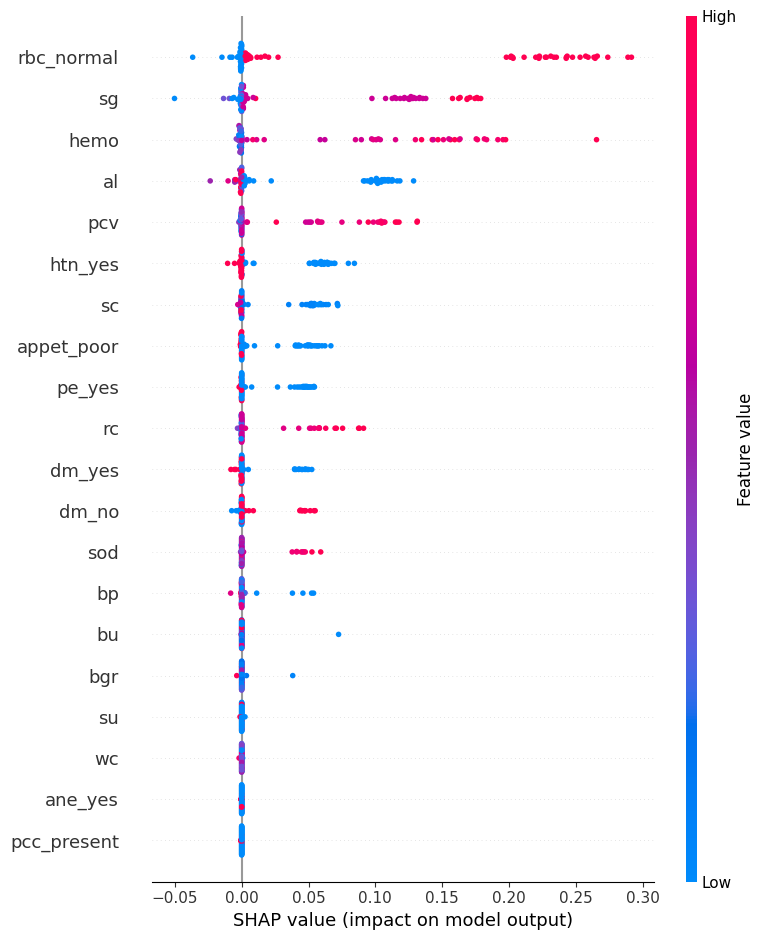

In [ ]:
import shap
import matplotlib.pyplot as plt


background_data = X_train_bal[:100]


explainer = shap.KernelExplainer(lambda x: stack.predict_proba(x)[:, 1], background_data)

shap_values = explainer.shap_values(X_test_scaled[:100])


plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_scaled[:100],
    feature_names=X_train.columns,
    plot_type="dot"
)


plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.utils import resample
import xgboost as xgb

# 1. Load data
data = pd.read_csv("kidney_disease.csv")

# 2. Preprocess & Clean Numeric Variables
num_cols = [
    "pcv",
    "wc",
    "rc",
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
]
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Clean target labels
data["classification"] = (
    data["classification"].str.replace(r"\t", "", regex=True).str.strip()
)
le = LabelEncoder()
data["Class"] = le.fit_transform(data["classification"])

# Encode categorical variables
data_encoded = pd.get_dummies(
    data.drop(["id", "classification"], axis=1), drop_first=True
)

# 3. Stratified Split
X = data_encoded.drop("Class", axis=1)
y = data_encoded["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Impute missing entries using Medians
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# 4. Handle Class Imbalance via Upsampling
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
major_class = train_data[train_data.Class == 0]
minor_class = train_data[train_data.Class == 1]

minor_upsampled = resample(
    minor_class, replace=True, n_samples=len(major_class), random_state=42
)

bal_data = pd.concat([major_class, minor_upsampled])
X_train_bal = bal_data.drop("Class", axis=1)
y_train_bal = bal_data["Class"]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# 5. Train & Evaluate Models
models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="logloss"),
}

trained_models = {}
model_scores = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_bal)
    trained_models[name] = model

    # Evaluate using PR-AUC (Average Precision)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    score = average_precision_score(y_test, probs)
    model_scores[name] = score

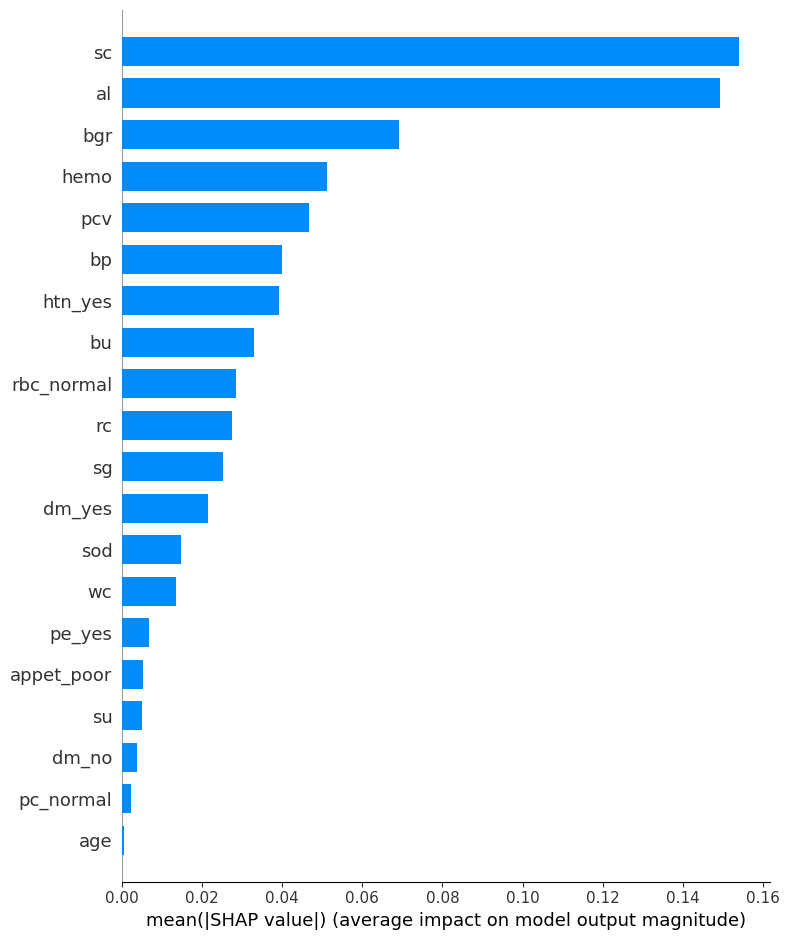

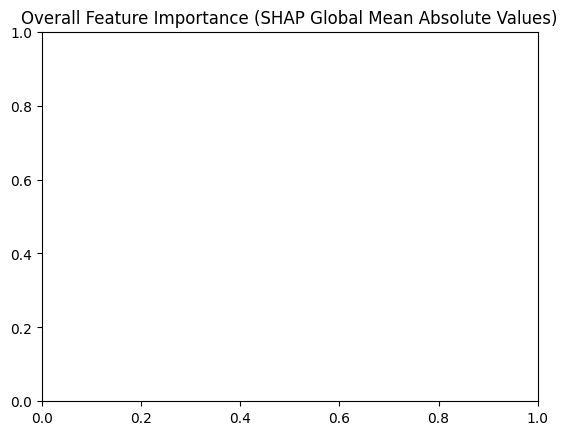

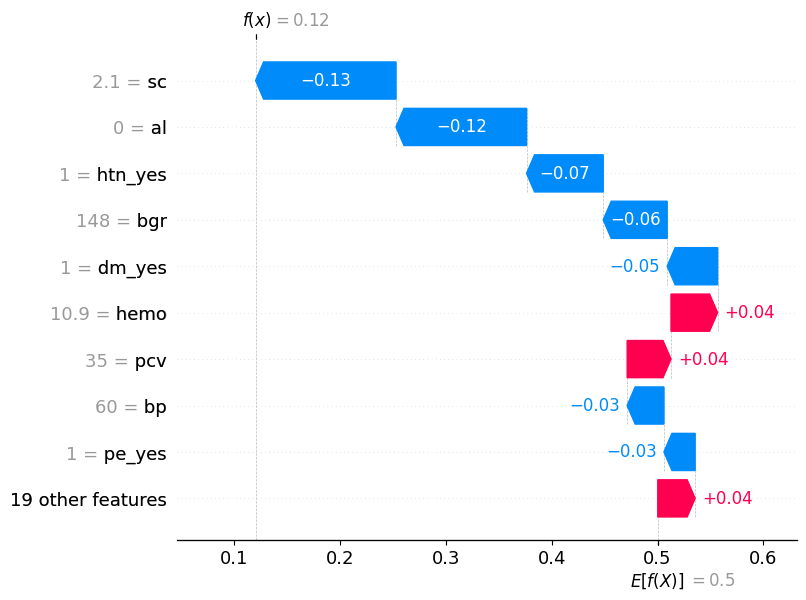

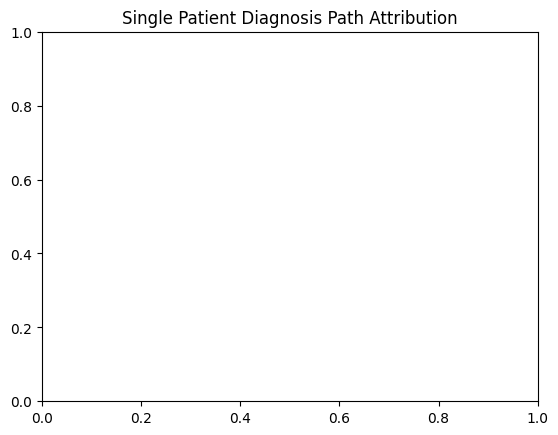

In [ ]:
import matplotlib.pyplot as plt
import shap

# Compute SHAP values using the TreeExplainer on Random Forest
explainer = shap.TreeExplainer(trained_models["RF"])
shap_values = explainer.shap_values(X_test)

# 1. Summary Plot (Beeswarm)
# Shows the distribution of the impact each feature has on the model output
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")
plt.title("Overall Feature Importance (SHAP Global Mean Absolute Values)")
plt.show()

# 2. Local Explanation Plot (Waterfall/Force plot for individual patient)
# Visualizes how features push the prediction away from the base value
plt.figure(figsize=(12, 4))
shap.plots.waterfall(explainer(X_test)[0][:, 1])
plt.title("Single Patient Diagnosis Path Attribution")
plt.show()

/tmp/ipykernel_1750/2979101314.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


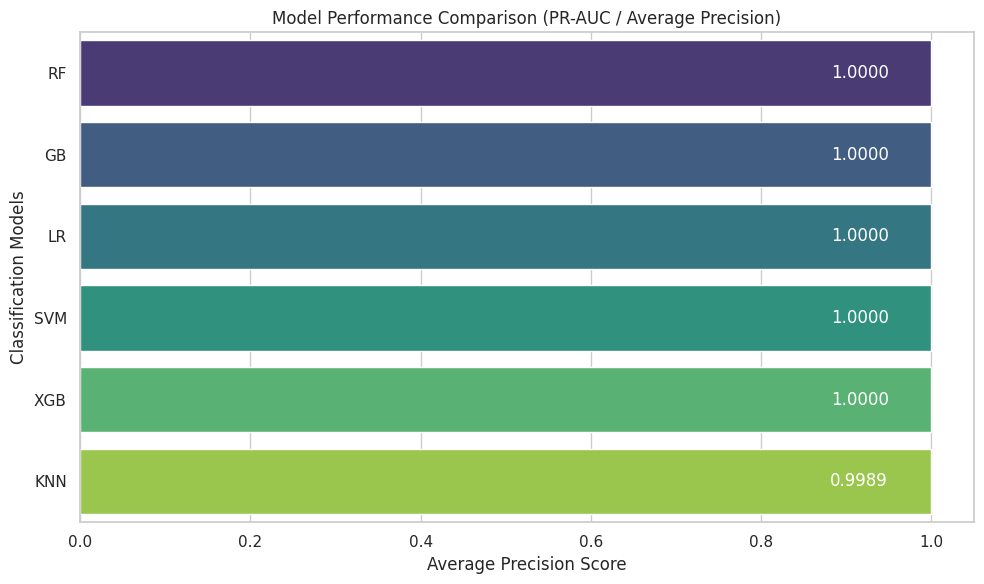

✓ Saved: model_performance_comparison.png


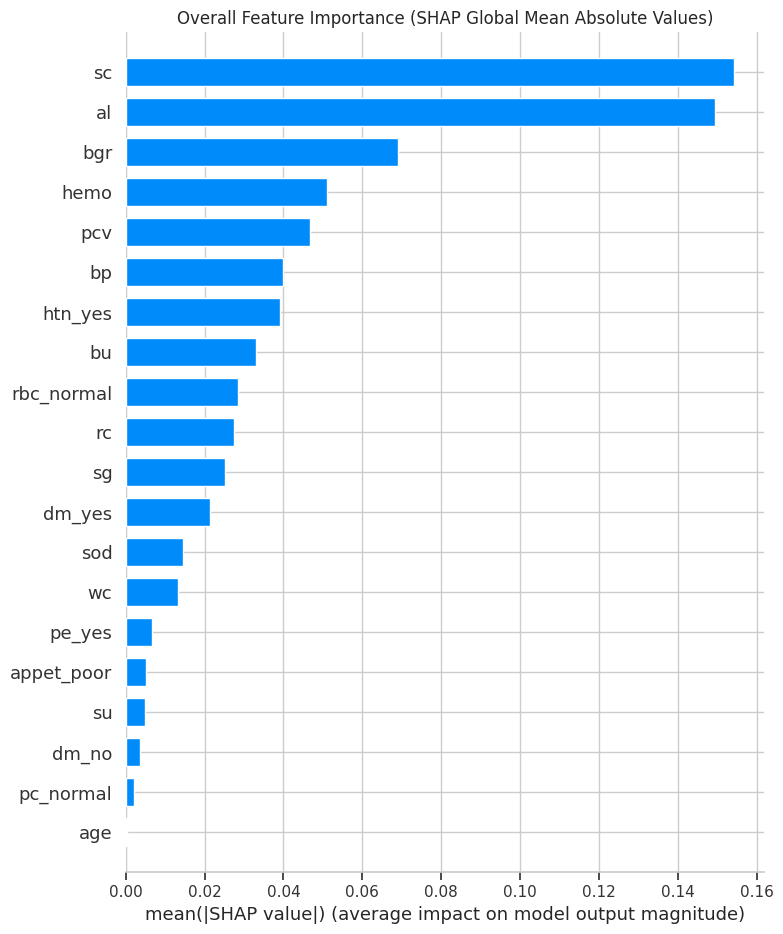

✓ Saved: shap_global_summary.png


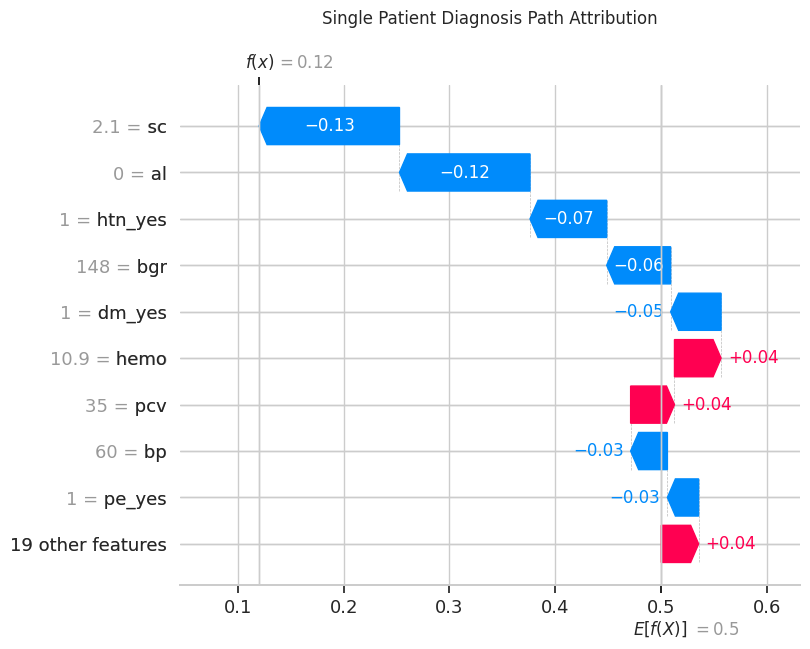

✓ Saved: shap_local_waterfall.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shap

# Set the style for clean, professional plots
sns.set_theme(style="whitegrid")

# ==========================================
# 1. SAVE PERFORMANCE VISUALIZATION PLOT
# ==========================================
# Sorting the model scores for a cleaner presentation
sorted_scores = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)
models_list, scores_list = zip(*sorted_scores)

plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x=list(scores_list), y=list(models_list), palette="viridis"
)

# Add exact score labels on top of each bar
for i, score in enumerate(scores_list):
    barplot.text(
        score - 0.05, i, f"{score:.4f}", va="center", ha="right", color="white"
    )

plt.title("Model Performance Comparison (PR-AUC / Average Precision)")
plt.xlabel("Average Precision Score")
plt.ylabel("Classification Models")
plt.xlim(0, 1.05)
plt.tight_layout()

# --- SAVE STEP ---
# bbox_inches='tight' ensures labels don't get cut off in the saved file
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()  # Clear memory
print("✓ Saved: model_performance_comparison.png")


# ==========================================
# 2. SAVE GLOBAL SHAP SUMMARY PLOT
# ==========================================
# Compute SHAP values using the Random Forest model
explainer = shap.TreeExplainer(trained_models["RF"])
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))

# Generate summary plot (SHAP handles its own internal layout, but respects the active figure)
# For multiclass/binary, we slice [:, :, 1] to look at the positive 'CKD' class impact
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=False)
plt.title("Overall Feature Importance (SHAP Global Mean Absolute Values)")
plt.tight_layout()

# --- SAVE STEP ---
plt.savefig("shap_global_summary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("✓ Saved: shap_global_summary.png")


# ==========================================
# 3. SAVE LOCAL SHAP WATERFALL PLOT
# ==========================================
# Explaining the first test instance (Patient index 0)
plt.figure(figsize=(12, 5))

# Get explanation object specifically for class 1
explanation_obj = explainer(X_test)

# --- SAVE STEP ---
# Note: SHAP plots sometimes close themselves on .plot(),
# so we use show=False to keep the canvas open long enough to save it.
shap.plots.waterfall(explanation_obj[0][:, 1], show=False)
plt.title("Single Patient Diagnosis Path Attribution", pad=20)

plt.savefig("shap_local_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("✓ Saved: shap_local_waterfall.png")

/tmp/ipykernel_1750/234878023.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


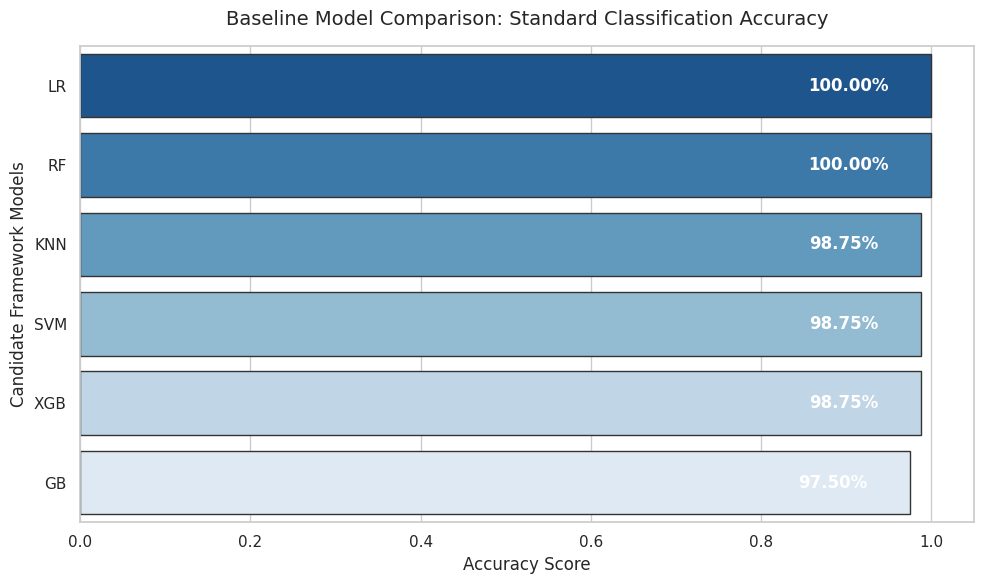

Calculated Accuracy Scores:
LR: 1.0000
RF: 1.0000
KNN: 0.9875
SVM: 0.9875
XGB: 0.9875
GB: 0.9750


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score

# 1. Compute Standard Accuracy for each model
model_accuracy = {}
for name, model in trained_models.items():
    # Predict hard labels (0 or 1)
    preds = model.predict(X_test_scaled)
    # Calculate accuracy score
    acc = accuracy_score(y_test, preds)
    model_accuracy[name] = acc

# 2. Configure academic-style plot
sns.set_theme(style="whitegrid")
sorted_accuracy = sorted(model_accuracy.items(), key=lambda x: x[1], reverse=True)
models_list, acc_list = zip(*sorted_accuracy)

plt.figure(figsize=(10, 6))
# Using a clean corporate/academic palette
barplot = sns.barplot(
    x=list(acc_list), y=list(models_list), palette="Blues_r", edgecolor="0.2"
)

# Insert exact numeric markers inside/edge of the bars
for i, acc in enumerate(acc_list):
    barplot.text(
        acc - 0.05, i, f"{acc*100:.2f}%", va="center", ha="right", color="white", fontweight="bold"
    )

plt.title("Baseline Model Comparison: Standard Classification Accuracy", fontsize=14, pad=15)
plt.xlabel("Accuracy Score", fontsize=12)
plt.ylabel("Candidate Framework Models", fontsize=12)
plt.xlim(0, 1.05)
plt.tight_layout()

# Save for Thesis (300 DPI is standard for print publications)
plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Print out raw metrics for confirmation
print("Calculated Accuracy Scores:")
for name, acc in sorted_accuracy:
    print(f"{name}: {acc:.4f}")